In [5]:
from pathlib import Path
from datetime import datetime
import json
import shutil

from hloc import extract_features, match_features, reconstruction, pairs_from_retrieval
from hloc.utils.read_write_model import read_model, write_model

# Kaynak veri ve çalışma klasörleri
source_dataset = Path("../datasets/dragos")
source_images_dir = source_dataset / "images"
portable_root = Path("../outputs/dragos-bundle")
portable_images_dir = portable_root / "images"
portable_sparse_dir = portable_root / "sparse"

portable_root.mkdir(parents=True, exist_ok=True)
portable_images_dir.mkdir(parents=True, exist_ok=True)
portable_sparse_dir.mkdir(parents=True, exist_ok=True)

# Bundle içindeki çalışma dosyaları
sfm_pairs = portable_root / "pairs-sfm.txt"
sfm_dir = portable_root / "sfm"
features = portable_root / "features.h5"
global_features = portable_root / "global-feats-netvlad.h5"
matches = portable_root / "matches.h5"
portable_database = portable_root / "database.db"
portable_sfm_pairs = portable_root / "pairs-sfm.txt"
portable_results = portable_root / "results.txt"
portable_metadata = portable_root / "metadata.json"

# SuperPoint, NetVLAD ve LightGlue konfigürasyonları
feature_conf = extract_features.confs["superpoint_max"]
retrieval_conf = extract_features.confs["netvlad"]
matcher_conf = match_features.confs["superpoint+lightglue"]
num_matched = 20

In [6]:
# Reconstruction görüntülerini bundle içindeki images klasörüne kopyala
for src in sorted(p for p in source_images_dir.iterdir() if p.is_file()):
    dst = portable_images_dir / src.name
    if not dst.exists():
        shutil.copy2(src, dst)

# Harita için kullanılacak göreli görüntü yolları
references = sorted([f"images/{p.name}" for p in portable_images_dir.iterdir() if p.is_file()])

# Yerel öznitelik çıkarımı
extract_features.main(
    feature_conf,
    portable_root,
    image_list=references,
    feature_path=features,
    overwrite=True,
)

[2026/03/26 00:11:23 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}


Loaded SuperPoint model


100%|██████████| 201/201 [00:16<00:00, 12.51it/s]
[2026/03/26 00:11:39 hloc INFO] Finished exporting features.


PosixPath('../outputs/dragos-bundle/features.h5')

In [7]:
# Global descriptor çıkarımı ve retrieval pair üretimi
references = sorted([f"images/{p.name}" for p in portable_images_dir.iterdir() if p.is_file()])

extract_features.main(
    retrieval_conf,
    portable_root,
    image_list=references,
    feature_path=global_features,
    overwrite=True,
)

pairs_from_retrieval.main(
    descriptors=global_features,
    output=sfm_pairs,
    num_matched=num_matched,
)

# LightGlue ile eşleştirme
match_features.main(
    matcher_conf,
    sfm_pairs,
    features=features,
    matches=matches,
    overwrite=True,
)

[2026/03/26 00:11:44 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'netvlad'},
 'output': 'global-feats-netvlad',
 'preprocessing': {'resize_max': 1024}}
100%|██████████| 201/201 [00:24<00:00,  8.30it/s]
[2026/03/26 00:12:14 hloc INFO] Finished exporting features.
[2026/03/26 00:12:14 hloc INFO] Extracting image pairs from a retrieval database.
[2026/03/26 00:12:15 hloc INFO] Found 4020 pairs.
[2026/03/26 00:12:15 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
100%|██████████| 2301/2301 [02:25<00:00, 15.83it/s]
[2026/03/26 00:14:40 hloc INFO] Finished exporting matches.


PosixPath('../outputs/dragos-bundle/matches.h5')

In [8]:
# Kamera kalibrasyonu biliniyorsa image_options ile verilebilir
# image_options = dict(camera_model='SIMPLE_RADIAL', camera_params='f,cx,cy,k')

references = sorted([f"images/{p.name}" for p in portable_images_dir.iterdir() if p.is_file()])

# 3B SfM modelinin inşası
model = reconstruction.main(
    sfm_dir,
    portable_root,
    sfm_pairs,
    features,
    matches,
    image_list=references,
)

# Reconstruction sonunda bundle içinde gerekli tüm dosyalar zaten mevcut
# database.db dosyası sfm klasöründe üretildiği için köke de kopyalıyoruz
shutil.copy2(sfm_dir / "database.db", portable_database)

# COLMAP sparse modelini txt olarak yaz
cameras, images_model, points3D = read_model(sfm_dir)
write_model(cameras, images_model, points3D, portable_sparse_dir, ext=".txt")

# COLMAP loglarını da sakla
for log_file in sfm_dir.glob("colmap.LOG.*"):
    if log_file.parent != portable_root:
        shutil.copy2(log_file, portable_root / log_file.name)

# Bundle metadatası
metadata = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "source_dataset": str(source_dataset),
    "bundle_root": str(portable_root),
    "image_count": len(references),
    "local_feature_conf": feature_conf["output"],
    "global_feature_conf": retrieval_conf["output"],
    "matcher_conf": matcher_conf["output"],
    "sfm_num_matched": num_matched,
    "files": {
        "database": portable_database.name,
        "features": features.name,
        "global_features": global_features.name,
        "matches": matches.name,
        "pairs_sfm": portable_sfm_pairs.name,
        "results": portable_results.name if portable_results.exists() else None,
        "images_dir": portable_images_dir.name,
        "sparse_dir": portable_sparse_dir.name,
    },
}
portable_metadata.write_text(json.dumps(metadata, indent=2))

print(f"Portable bundle root: {portable_root.resolve()}")
print(f"- database: {portable_database.name}")
print(f"- features: {features.name}")
print(f"- global features: {global_features.name}")
print(f"- matches: {matches.name}")
print(f"- sfm pairs: {portable_sfm_pairs.name}")
print(f"- images: {portable_images_dir}")
print(f"- sparse txt: {portable_sparse_dir}")
print(f"- metadata: {portable_metadata.name}")

[2026/03/26 00:14:48 hloc INFO] Writing COLMAP logs to ../outputs/dragos-bundle/sfm/colmap.LOG.*
[2026/03/26 00:14:48 hloc INFO] Creating an empty database...
[2026/03/26 00:14:48 hloc INFO] Importing images into the database...
[2026/03/26 00:15:01 hloc INFO] Importing features into the database...
100%|██████████| 201/201 [00:00<00:00, 1776.04it/s]
[2026/03/26 00:15:01 hloc INFO] Importing matches into the database...
100%|██████████| 4020/4020 [00:01<00:00, 2349.92it/s]
[2026/03/26 00:15:03 hloc INFO] Performing geometric verification of the matches...
[2026/03/26 00:15:19 hloc INFO] Running 3D reconstruction...
Reconstruction 10:   1%|          | 2/201 [00:00<00:49,  4.02images/s, registered]
Reconstruction 11: 203images [10:02,  2.97s/images, registered]                     
[2026/03/26 00:26:07 hloc INFO] Reconstructed 2 model(s).
[2026/03/26 00:26:07 hloc INFO] Largest model is #1 with 201 images.
[2026/03/26 00:26:07 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_ri

Portable bundle root: /home/yegezici/Desktop/Hierarchical-Localization/outputs/dragos-bundle
- database: database.db
- features: features.h5
- global features: global-feats-netvlad.h5
- matches: matches.h5
- sfm pairs: pairs-sfm.txt
- images: ../outputs/dragos-bundle/images
- sparse txt: ../outputs/dragos-bundle/sparse
- metadata: metadata.json


In [9]:
# Model özeti ve temel istatistikler
import pycolmap

sfm_model = portable_sparse_dir
viz_model = pycolmap.Reconstruction(sfm_model)

print(viz_model.summary())
print(f"Registered images: {viz_model.num_reg_images()}")
print(f"Total images: {len(viz_model.images)}")
print(f"3D points: {len(viz_model.points3D)}")

Reconstruction:
	num_rigs = 3
	num_cameras = 3
	num_frames = 3
	num_reg_frames = 3
	num_images = 3
	num_points3D = 387
	num_observations = 783
	mean_track_length = 2.02326
	mean_observations_per_image = 261
	mean_reprojection_error = 0.696489
Registered images: 3
Total images: 3
3D points: 387


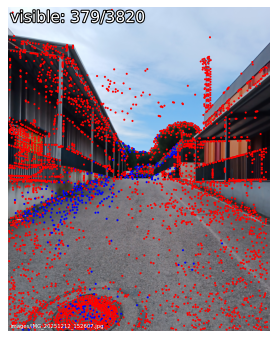

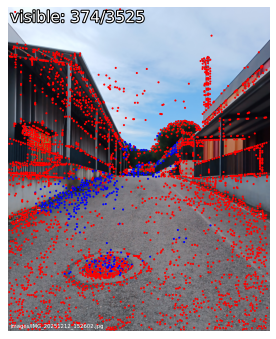

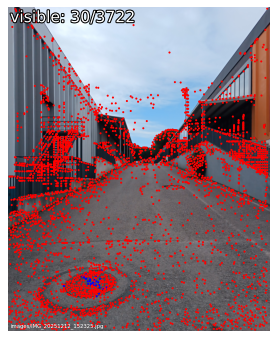

In [12]:
# 2D SfM görselleştirmesi
from hloc import visualization

visualization.visualize_sfm_2d(viz_model, portable_root, color_by="visibility", n=5)

In [11]:
# 3D interaktif görselleştirme
from hloc.utils import viz_3d

fig = viz_3d.init_figure()
viz_3d.plot_reconstruction(
    fig,
    viz_model,
    color="rgba(255,0,0,0.5)",
    name="south-building",
    points_rgb=True,
)
fig.show()